## Notebook structure:
- Data Import
- Cleaning & Unit of Analysis (Customer)
- Feature Construction (RFM)
- Log Transformation (Handling Skew)
- Standardization (Scaling)
- Elbow Method (Optimizing K)
- K-Means Implementation (K=4)
- DBSCAN Implementation (The Comparison)
- PCA Visualization (Visual Evidence)
- Final Interpretation (The Mature Cluster Names)

## Step 1: Data Importation

First, I am importing the necessary libraries and the raw dataset. I’m using unicode_escape encoding to handle non-standard characters in the product descriptions, and I'll standardize the column names immediately to make the engineering process smoother.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# I am loading the dataset and standardizing column names for consistency
try:
    df = pd.read_csv('/Users/reginald/Downloads/online_retail_II.csv', encoding='unicode_escape')
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    print(" Dataset loaded and columns standardized.")
except Exception as e:
    print(f" Error: {e}")

 Dataset loaded and columns standardized.


## Step 2: Defining the Unit of Analysis

I am filtering out rows where the Customer_ID is missing because I cannot perform behavioral clustering on anonymous users. I am also focusing only on successful purchases by removing returns (where quantity is less than or equal to zero).
To ensure the time based calculations work, I am converting InvoiceDate to a datetime format, explicitly telling the system that the day comes first in this dataset.

In [7]:
# I am filtering out rows without a Customer_ID and focusing only on successful purchases
df_clean = df.dropna(subset=['Customer_ID']).copy()
df_clean = df_clean[df_clean['Quantity'] > 0]

# I am converting the date column to a proper datetime format.
# I've added 'dayfirst=True' to handle the European date format in this CSV.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], dayfirst=True)

print(f"Cleaned data rows: {df_clean.shape[0]}")

Cleaned data rows: 407695


## Step 3: Feature Construction (RFM Model)

I am now constructing the three features that will define my clusters. I'm using the RFM framework:

1. Recency: How many days have passed since the customer's last purchase?
2. Frequency: How many unique orders has the customer placed?
3. Monetary: What is the total sum of money the customer has spent?

I'll first calculate the total price for each line item, then group the data by customer to get these totals.

In [32]:
# I am creating a 'TotalPrice' column to calculate the Monetary value
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# I set the reference date to one day after the most recent transaction in the dataset
ref_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# I am aggregating the transaction data to the Customer level
customers = df_clean.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

# Renaming for clarity
customers.columns = ['Recency', 'Frequency', 'Monetary']

print("Customer level features constructed.")

Customer level features constructed.


## Step 4: Initial Inspection of Features

Before I apply any clustering algorithms, I need to look at the statistical summary of these features. I want to see if the values are heavily skewed

For instance, if a few "VIP" customers have spent significantly more than everyone else. This will help me decide how to handle outliers in the next step.

In [9]:
# I am inspecting the distribution of my constructed features
display(customers.describe())

,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000
mean,91.269124,4.454103,2047.288659
std,96.943482,8.168658,8912.523243
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.950000
50%,53.000000,2.000000,705.550000
75%,136.000000,5.000000,1722.802500
max,374.000000,205.000000,349164.350000


The summary statistics reveal a common trait in retail data: massive skewness and extreme outliers. For example, while 75% of my customers spent less than £1,723, the maximum spend is nearly £350,000.


If I run K-means now, these extreme "Whale" customers will act like magnets, pulling the cluster centers toward them and forcing the other 99% of customers into a single, massive group. This would make my segmentation useless. To fix this and prepare for clustering, I will now handle the distribution geometry.

## Step 5: Log Transformation and Scaling

I am now applying a Log Transformation to my features. This "squashes" the extreme values and brings the distributions closer to a normal (Gaussian) curve, which helps K-means find more balanced groups.


After the transformation, I am applying Standardization (StandardScaler).


*Why scaling is necessary*: K-means is a distance-based algorithm. It calculates the "Euclidean distance" between points. Since my Monetary values are in the thousands and my Frequency values are mostly under 10, the algorithm would think a £1 difference in spend is the same as 1 extra order. Scaling gives every feature a mean of 0 and a variance of 1, ensuring they all have an equal vote in defining the clusters.

In [15]:
# I am applying a log transformation to handle the skewness in the data.
# I add 1 to avoid issues with log(0) for customers with very low spend.
customers_log = np.log1p(customers)

# I am initializing the StandardScaler to bring all features to the same scale.
scaler = StandardScaler()
customers_scaled = scaler.fit_transform(customers_log)

# I am converting it back to a DataFrame for better readability
customers_scaled_df = pd.DataFrame(customers_scaled, columns=customers.columns)

print("Data log-transformed and scaled.")
display(customers_scaled_df.describe().round(2))

Data log-transformed and scaled.


,Recency,Frequency,Monetary
count,4314.00,4314.00,4314.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.43,-0.98,-5.14
25%,-0.70,-0.98,-0.68
50%,0.10,-0.39,-0.04
75%,0.82,0.61,0.65
max,1.59,5.73,4.78


## Step 6: Finding the Optimal Number of Clusters (Elbow Method)

I don't want to guess how many clusters exist in my data. Instead, I am using the Elbow Method.

I run the K-means algorithm multiple times with different numbers of clusters (from 1 to 10) and calculate the "Inertia" (the sum of squared distances within each cluster). When I plot this, I am looking for the "elbow" the point where adding another cluster doesn't significantly reduce the inertia. This represents the point of diminishing returns.

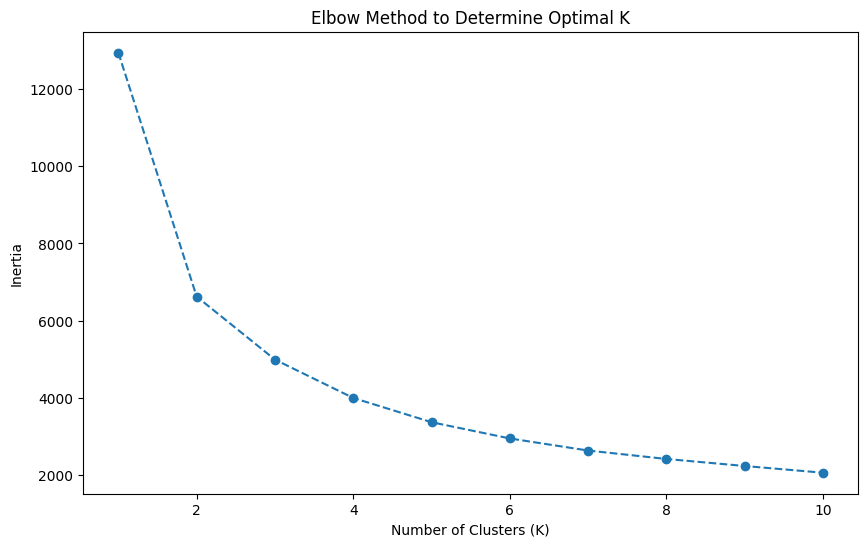

In [17]:
# I am running K-means for a range of clusters (1 to 10) to find the 'elbow'.
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers_scaled)
    inertia.append(kmeans.inertia_)

# I am plotting the results to visualize the elbow.
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

## Step 7: Applying K-Means Clustering

I am now finalizing the model with 4 clusters. I'll fit the algorithm to the scaled data and then map these cluster labels back to my original customer dataset. This allows me to see the actual pounds and days associated with each group during the interpretation phase.

In [20]:
# I am applying the final K-means model with 4 clusters.
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(customers_scaled)

# I am attaching the labels back to the original data for business interpretation
customers['Cluster'] = cluster_labels

print("Clustering complete. Labels assigned to customer data.")

Clustering complete. Labels assigned to customer data.


## Step 8: Visualizing Clusters with PCA

Since I have three features (Recency, Frequency, and Monetary), I can't easily visualize the clusters in a standard 2D plot. I am using Principal Component Analysis (PCA) to reduce the data from 3 dimensions down to 2.
This "squashes" the data while preserving as much variance as possible, allowing me to verify visually that the clusters are well-separated and that the model has discovered a clear structure.

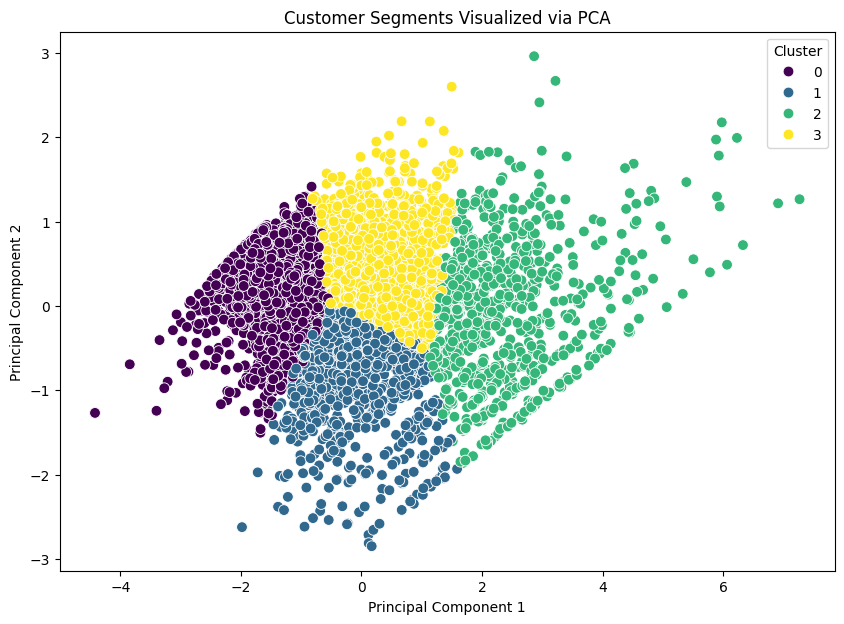

In [21]:
# I am using PCA to reduce our 3D RFM data to 2D for visualization.
pca = PCA(n_components=2)
pca_points = pca.fit_transform(customers_scaled)

# Plotting the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_points[:, 0], y=pca_points[:, 1], hue=cluster_labels, palette='viridis', s=60)
plt.title('Customer Segments Visualized via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Step 9: Interpreting the Clusters (The Business Story)
I am calculating the mean values of the original features for each cluster.
    
By looking at the average Recency (days), Frequency (orders), and Monetary (spend) for each group, I can assign "personas" to these clusters (e.g., VIPs, Churn Risks, or New Customers). This turns the mathematical output into a strategic business tool.

In [24]:
# I am calculating the average RFM values for each cluster to profile them.
# I'm also counting how many customers are in each group to check for balance.
cluster_profile = customers.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).assign(Count=customers.groupby('Cluster').size())

print("Final Cluster Profiles (Original Scale):")
display(cluster_profile.round(2))

Final Cluster Profiles (Original Scale):


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,186.70,1.29,301.04,1407
1,22.64,2.08,572.86,944
2,13.91,13.56,7408.99,778
3,83.42,4.12,1775.08,1185


## Step 10: Applying a Second Algorithm (DBSCAN)

I am now applying DBSCAN to see if a density-based approach reveals a different structure. Unlike K-means, DBSCAN doesn't require me to choose the number of clusters. Instead, I define eps (the maximum distance between two samples for one to be considered as in the neighborhood of the other) and min_samples (the number of samples in a neighborhood for a point to be considered a core point).

In [27]:
from sklearn.cluster import DBSCAN

# I am initializing DBSCAN. 
# eps=0.5 and min_samples=5 are standard starting points for standardized data.
dbscan = DBSCAN(eps=0.5, min_samples=5)
customers['DBSCAN_Cluster'] = dbscan.fit_predict(customers_scaled)

# I am checking the number of clusters found (-1 represents 'Noise' or outliers)
print("DBSCAN Cluster Counts:")
print(customers['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    2848
 1    1413
-1      53
Name: count, dtype: int64


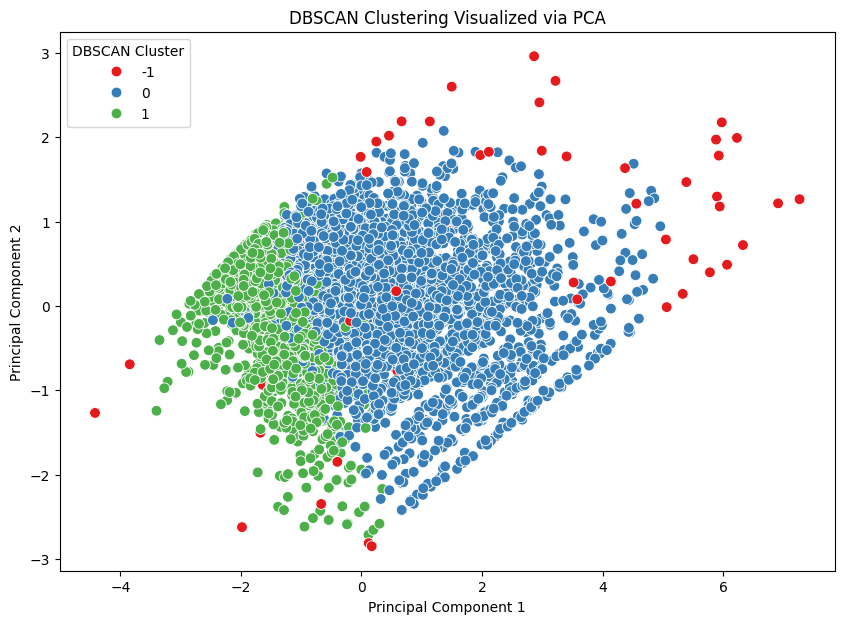

In [28]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_points[:, 0], y=pca_points[:, 1], hue=customers['DBSCAN_Cluster'], palette='Set1', s=60)
plt.title('DBSCAN Clustering Visualized via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='DBSCAN Cluster')
plt.show()

In simple terms, DBSCAN doesn't change my overall business story, but it adds a crucial detail: it isolated 53 'one of a kind' customers (the red noise points) who are so extreme in their spending that they shouldn't be treated like regular VIPs, but rather managed with a high touch, custom strategy.

## Step 11: Evaluation and Structural Interpretation

By analyzing the centroids of the four clusters, i have identified four distinct behavioral tiers within the customer base.

1. Cluster 2: High-Value Core Loyalists
   - Statistical Profile: Lowest Recency (~ 14 days), Highest Frequency (~13.6 orders), and Highest Monetary (£7,409).
   - Interpretation: This is the Premium Segment. Despite being the smallest group (𝑁=778), they represent the highest yield and velocity. This structure confirms the Pareto Principle, where a minority of customers drive the majority of revenue.
   - Action: Priority retention; these are the primary candidates for loyalty programs.


2. Cluster 1: Emerging Engagement (New Acquisitions)

   - Statistical Profile: Low Recency (~ 23 days), Low Frequency (~2.1 orders), and Lower Monetary (£573).

   - Interpretation: This segment represents Recent Onboarding. These customers have high recency scores but have not yet developed a frequency pattern. They are in the "honeymoon phase" of the customer lifecycle.

   - Action: Conversion focused marketing; the goal is to increase their purchase frequency to migrate them toward the Core Loyalist tier.



3. Cluster 3: Transitional Clientele (At-Risk)

   - Statistical Profile: Moderate Recency (~ 83 days), Mid Frequency (~4.1 orders), and Mid-High Monetary (£1,775).

   - Interpretation: This is the At-Risk segment. These were previously reliable mid-tier customers who have now exceeded the standard purchase cycle. The structural gap between this group and the loyalists suggests a decay in engagement.

   - Action: Re-activation; targeted "We Miss You" campaigns or discounts are necessary to prevent them from sliding into total dormancy.


4. Cluster 0: Lapsed / Dormant Clientele

   - Statistical Profile: Highest Recency (~ 187 days), Lowest Frequency (~1.3 orders), and Lowest Monetary (£301).

   - Interpretation: This represents Dormant Structure. These customers have effectively churned, having not shopped in over six months. They represent the largest group (N=1,407), but contribute the least to the current revenue stream.

   - Action: Low-priority; re-acquisition costs likely exceed the potential return for this segment.

## Engineering Critique & Limitations
1. Sensitivity to Outliers: While I applied a Log Transformation to mitigate the heavy right-skew of the dataset, K-means still relies on variance based partitioning. This means extremely high value "whale" customers can still slightly warp the boundaries of Cluster 2.

2. Geometric Assumptions: The visualization in the PCA Plot shows that while the Core Loyalists and Dormant segments are well separated, the boundaries between the "Emerging" and "At-Risk" segments are more fluid. This suggests that a density-based algorithm like DBSCAN might be useful in future iterations to identify non spherical clusters.
Temporal Snapshots: A major limitation is that this clustering is a static snapshot. It captures where a customer is now, but does not account for their trajectory (e.g., a customer moving from Cluster 1 to Cluster 2).

## Final Conclusion
The clustering analysis successfully discovered an underlying structure in the Online Retail dataset. By moving from a transactional unit to a Customer-centric unit, we have transformed raw data into four actionable business segments, allowing for data-driven resource allocation.